In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/cost_of_living_us.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
0,1,AL,True,"Montgomery, AL MSA",Autauga County,1p0c,8505.72876,3454.91712,10829.16876,5737.47984,4333.81344,0.0000,6392.94504,39254.0532,73010.414062
1,1,AL,True,"Montgomery, AL MSA",Autauga County,1p1c,12067.50240,5091.70788,11588.19288,8659.55640,6217.45896,6147.8298,7422.07836,57194.3256,73010.414062
2,1,AL,True,"Montgomery, AL MSA",Autauga County,1p2c,12067.50240,7460.20308,12361.77720,11581.63260,7075.65816,15824.6940,9769.56228,76141.0308,73010.414062
3,1,AL,True,"Montgomery, AL MSA",Autauga County,1p3c,15257.15040,9952.23924,13452.18600,14503.70760,9134.35620,18802.1892,13101.70320,94203.5328,73010.414062
4,1,AL,True,"Montgomery, AL MSA",Autauga County,1p4c,15257.15040,12182.21400,13744.59840,17425.78560,9942.36396,18802.1892,13469.21880,100823.5200,73010.414062


1.

In [3]:
print(f"Shape of DataFrame before dropping nulls: {df.shape}")

df_cleaned = df.dropna()

print(f"Shape of DataFrame after dropping nulls: {df_cleaned.shape}")

display(df_cleaned.head())

Shape of DataFrame before dropping nulls: (31430, 15)
Shape of DataFrame after dropping nulls: (31420, 15)


,case_id,state,isMetro,areaname,county,family_member_count,housing_cost,food_cost,transportation_cost,healthcare_cost,other_necessities_cost,childcare_cost,taxes,total_cost,median_family_income
0,1,AL,True,"Montgomery, AL MSA",Autauga County,1p0c,8505.72876,3454.91712,10829.16876,5737.47984,4333.81344,0.0000,6392.94504,39254.0532,73010.414062
1,1,AL,True,"Montgomery, AL MSA",Autauga County,1p1c,12067.50240,5091.70788,11588.19288,8659.55640,6217.45896,6147.8298,7422.07836,57194.3256,73010.414062
2,1,AL,True,"Montgomery, AL MSA",Autauga County,1p2c,12067.50240,7460.20308,12361.77720,11581.63260,7075.65816,15824.6940,9769.56228,76141.0308,73010.414062
3,1,AL,True,"Montgomery, AL MSA",Autauga County,1p3c,15257.15040,9952.23924,13452.18600,14503.70760,9134.35620,18802.1892,13101.70320,94203.5328,73010.414062
4,1,AL,True,"Montgomery, AL MSA",Autauga County,1p4c,15257.15040,12182.21400,13744.59840,17425.78560,9942.36396,18802.1892,13469.21880,100823.5200,73010.414062


2.

In [4]:
# Install itables for interactive table display
%pip install itables

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.4 MB/s eta 0:00:00


In [5]:
from itables import init_notebook_mode, show
init_notebook_mode(all_interactive=True)

# Select relevant cost columns for summarization
cost_columns = [
    'housing_cost',
    'food_cost',
    'transportation_cost',
    'healthcare_cost',
    'other_necessities_cost',
    'childcare_cost',
    'taxes',
    'total_cost',
    'median_family_income'
]

# Group by 'state' and calculate the mean of cost columns
df_summary = df_cleaned.groupby('state')[cost_columns].mean().reset_index()

# Round the values to 2 decimal places for better readability
df_summary = df_summary.round(2)

# Display the interactive summary table
show(df_summary, scrollX=True, paging=True)

Loading ITables v2.7.3 from the internet... (need help?)


3.

/tmp/ipykernel_34971/715830602.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/715830602.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/715830602.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/715830602.py:22: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/715830602.py:22: FutureWarning:



Passing `palette` without assigning `hue` is depreca

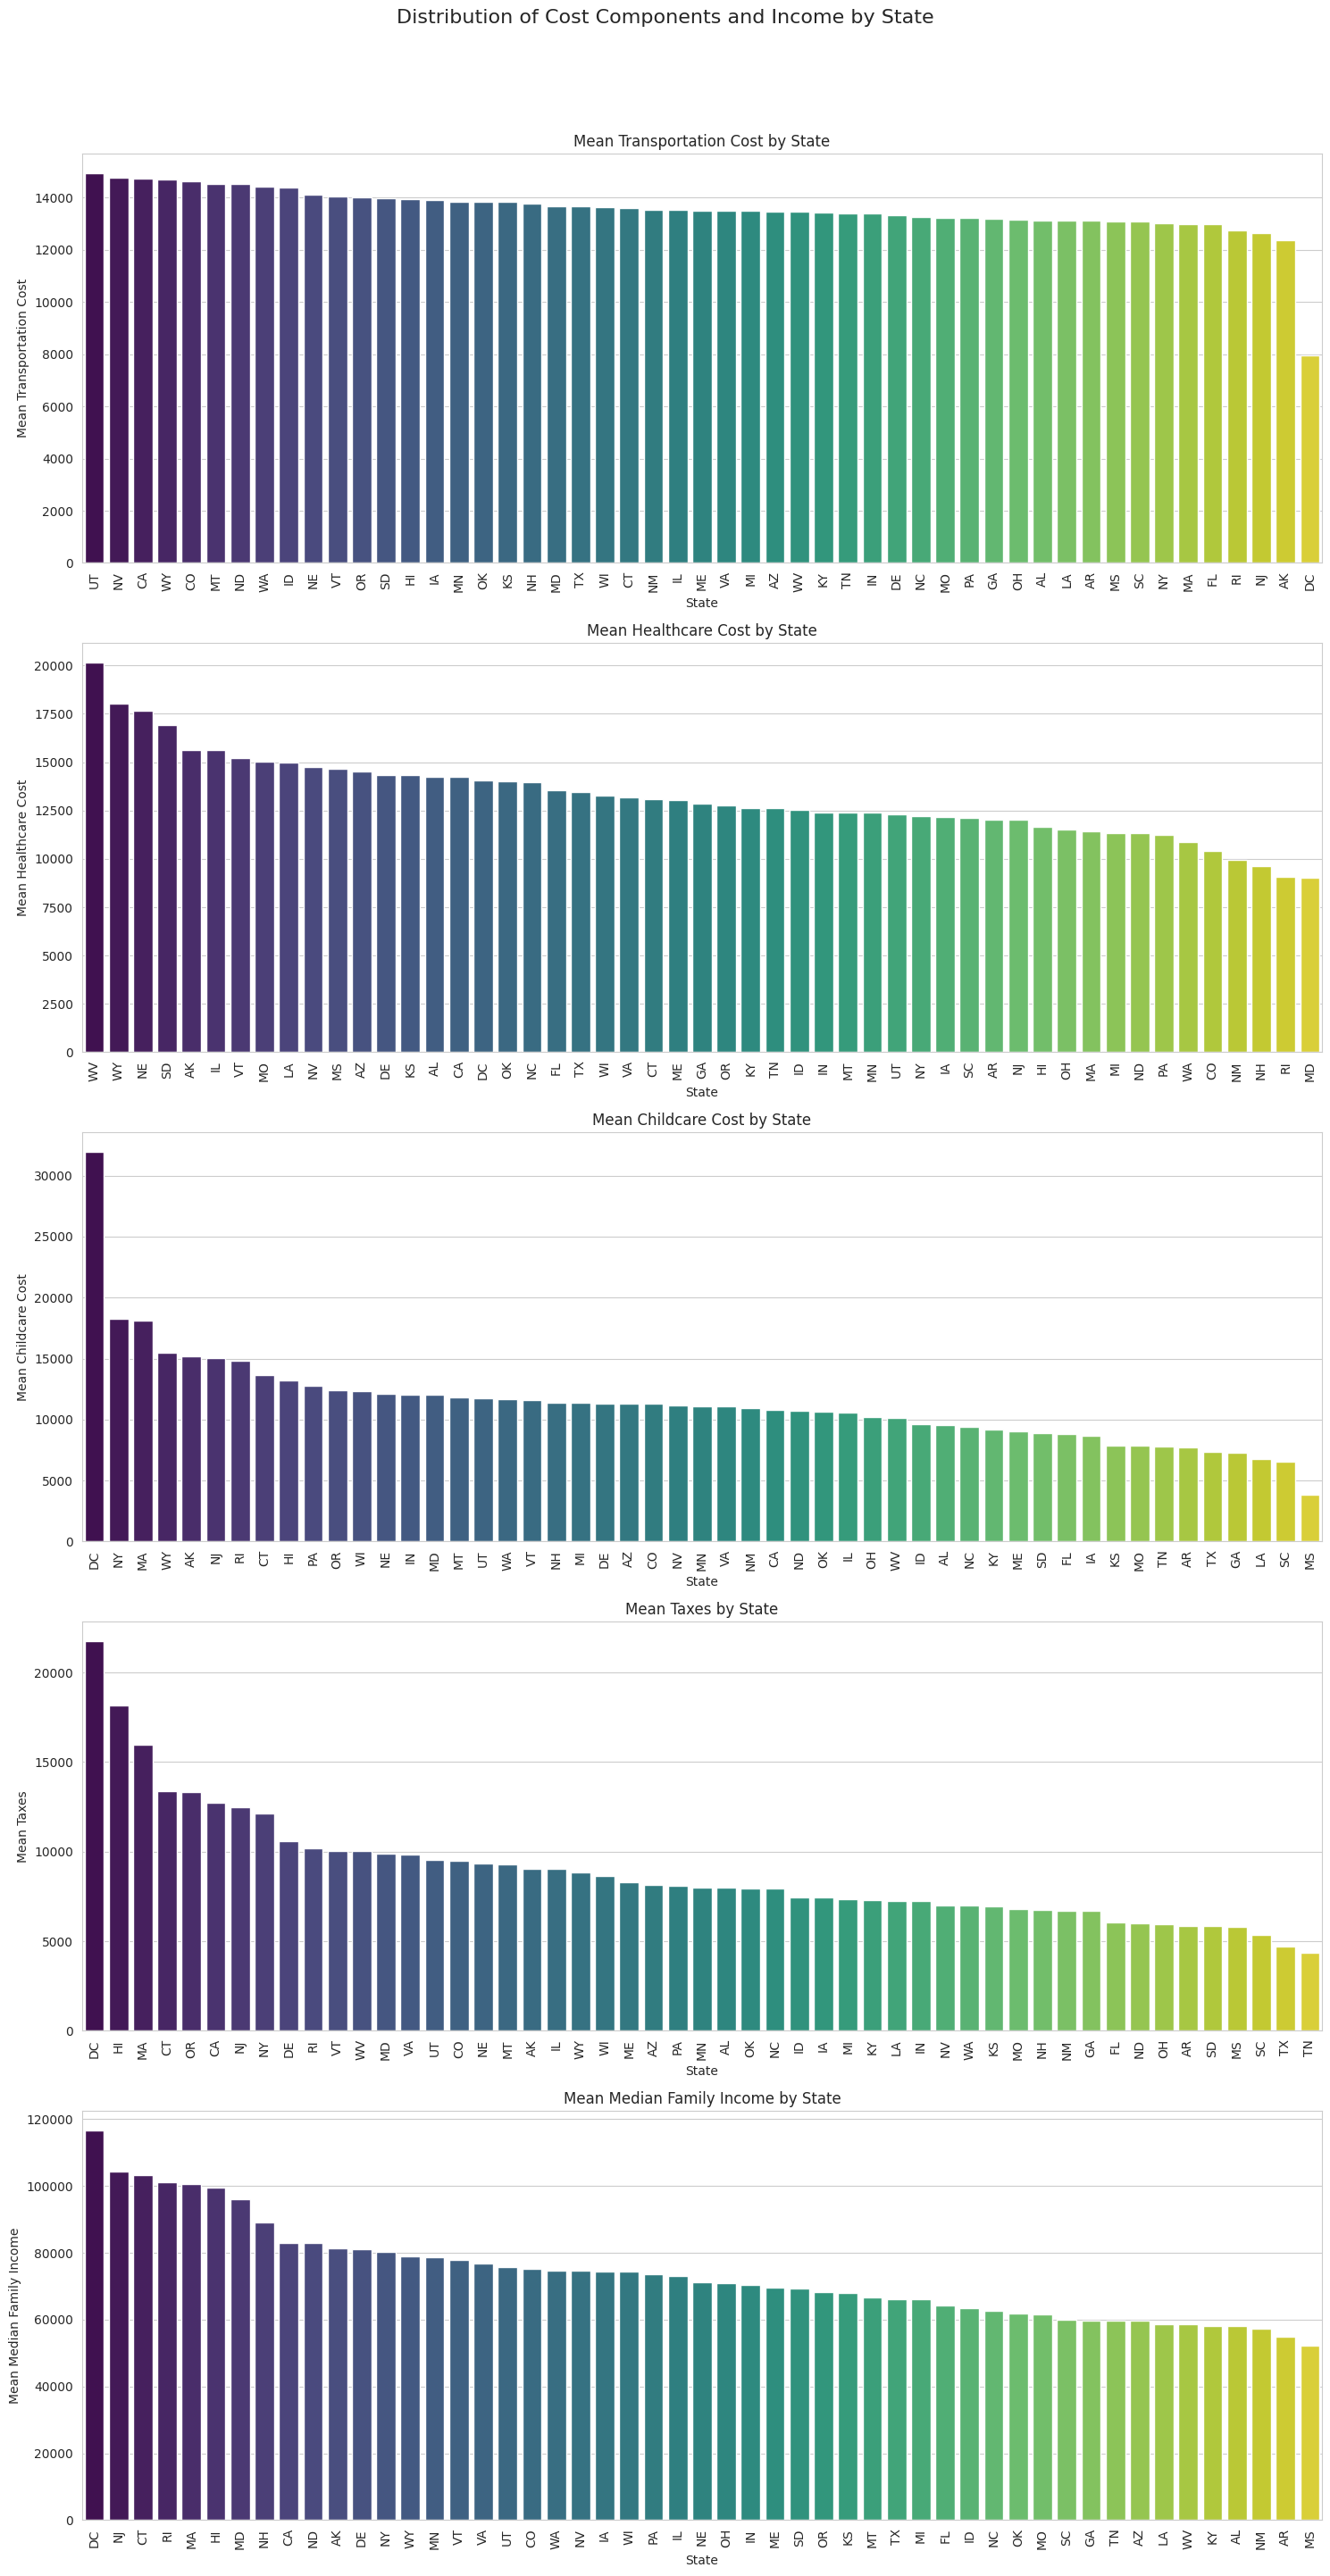

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a consistent style for the plots
sns.set_style("whitegrid")

# List of columns to plot from df_summary
plot_columns_summary = [
    'transportation_cost',
    'healthcare_cost',
    'childcare_cost',
    'taxes',
    'median_family_income'
]

# Create a figure to hold all subplots
fig, axes = plt.subplots(len(plot_columns_summary), 1, figsize=(15, 6 * len(plot_columns_summary)))
fig.suptitle('Distribution of Cost Components and Income by State', y=0.99, fontsize=16)

for i, col in enumerate(plot_columns_summary):
    ax = axes[i]
    sns.barplot(x='state', y=col, data=df_summary.sort_values(by=col, ascending=False), palette='viridis', ax=ax)
    ax.set_title(f'Mean {col.replace("_", " ").title()} by State')
    ax.set_xlabel('State')
    ax.set_ylabel(f'Mean {col.replace("_", " ").title()}')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent title overlap
plt.show()

Loading ITables v2.7.3 from the internet... (need help?)


/tmp/ipykernel_34971/3506084948.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/3506084948.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/3506084948.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/3506084948.py:26: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_34971/3506084948.py:26: FutureWarning:



Passing `palette` without assigning `hue` is de

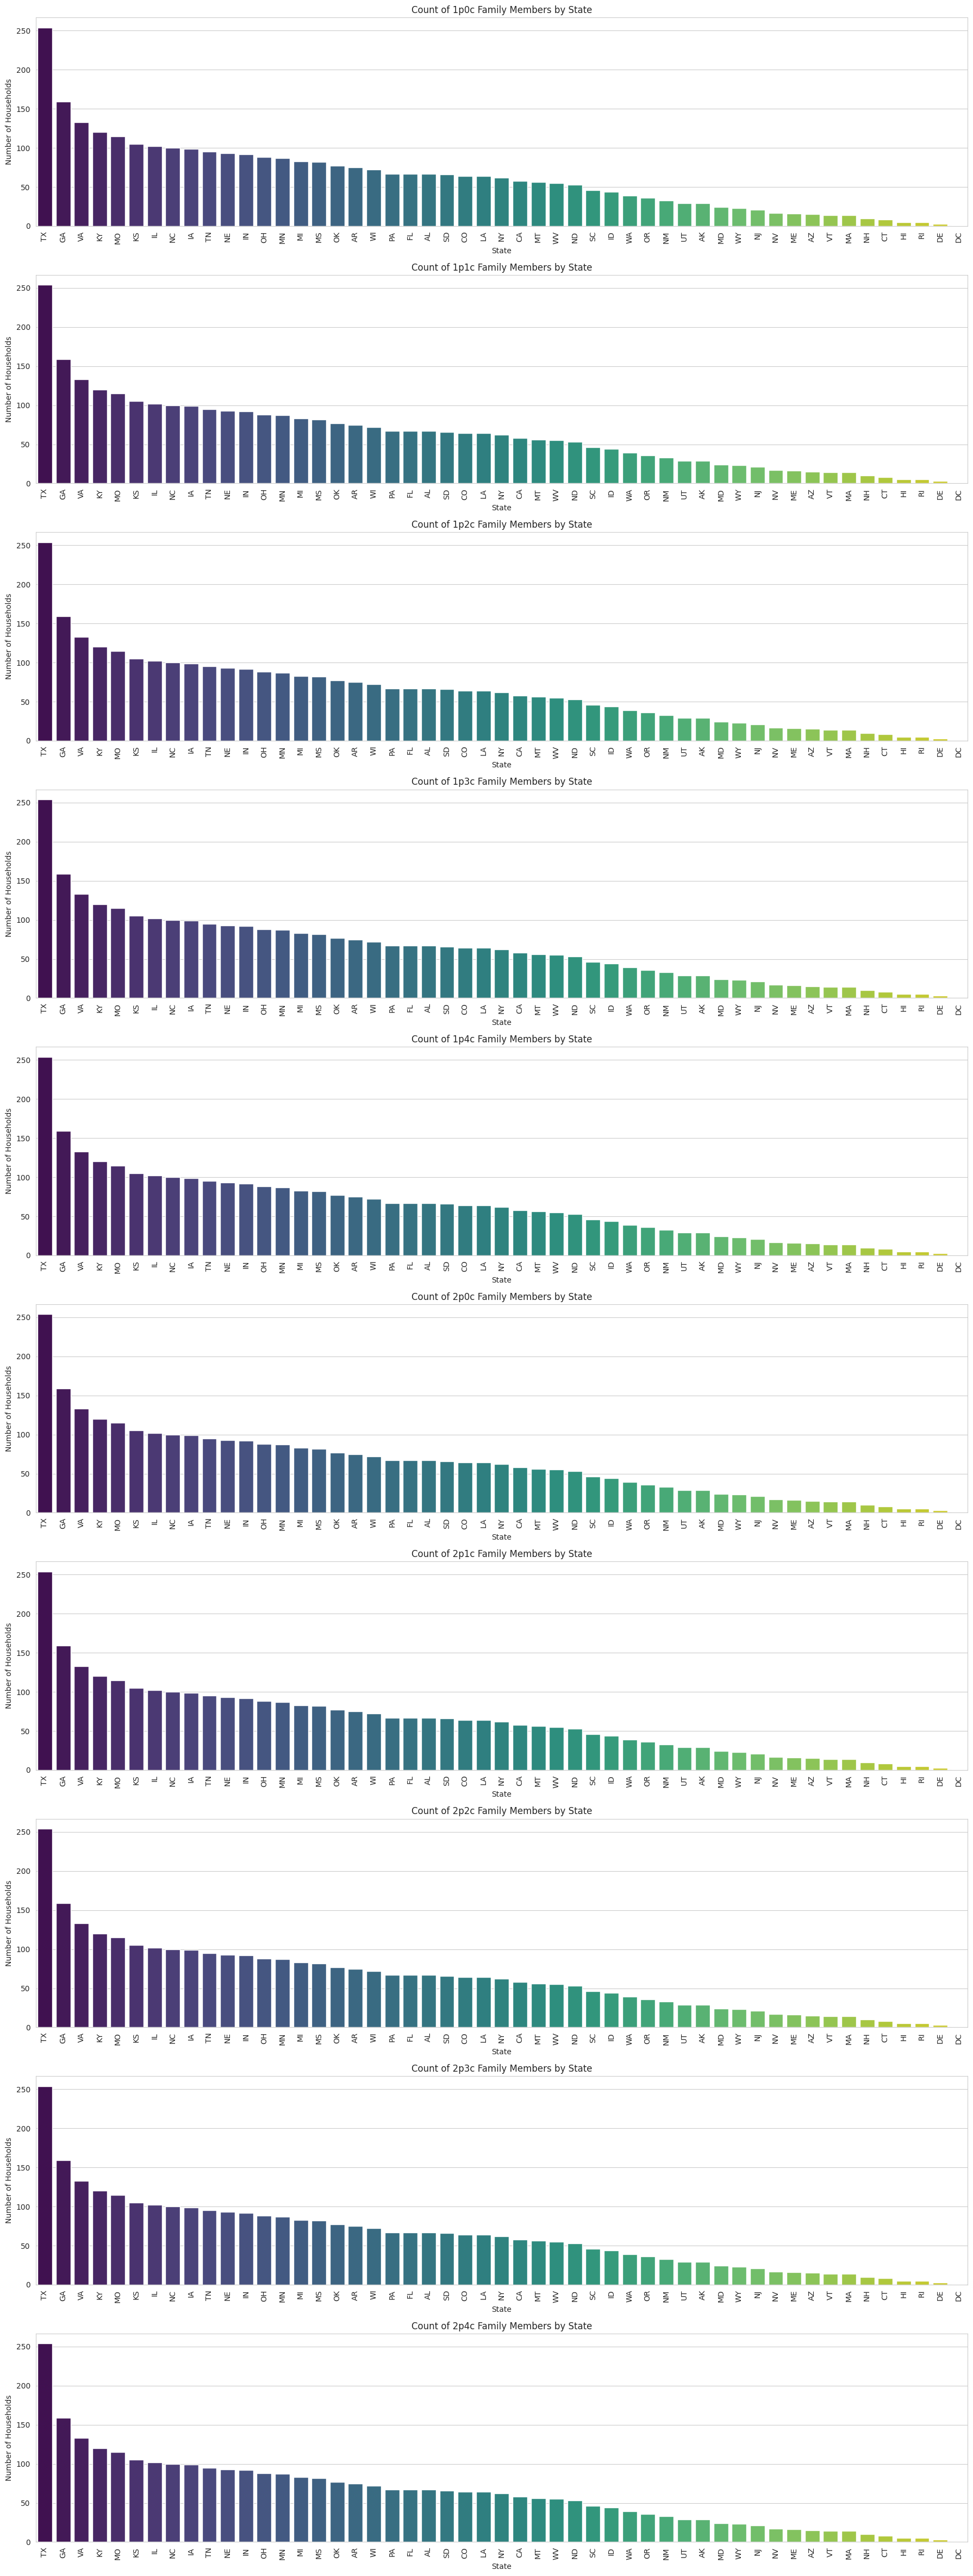

In [17]:
# Calculate the count of each 'family_member_count' for every state
family_counts_by_state = df_cleaned.groupby(['state', 'family_member_count']).size().reset_index(name='count')

# Display the first few rows of the new DataFrame
display(family_counts_by_state.head())

# Get unique family member count types for plotting
unique_family_types = family_counts_by_state['family_member_count'].unique()
unique_family_types.sort()

# Create a figure to hold all subplots dynamically
num_family_types = len(unique_family_types)
fig, axes = plt.subplots(num_family_types, 1, figsize=(18, 5 * num_family_types), sharex=False, sharey=False)

# Flatten axes array for easy iteration if there's only one subplot
if num_family_types == 1:
    axes = [axes]

for i, family_type in enumerate(unique_family_types):
    ax = axes[i]
    subset_df = family_counts_by_state[family_counts_by_state['family_member_count'] == family_type]

    # Sort states by count for better readability
    subset_df_sorted = subset_df.sort_values(by='count', ascending=False)

    sns.barplot(x='state', y='count', data=subset_df_sorted, palette='viridis', ax=ax)
    ax.set_title(f'Count of {family_type} Family Members by State')
    ax.set_xlabel('State')
    ax.set_ylabel('Number of Households')
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

4.

In [18]:
from itables import options

# Define the columns to apply styling to (all numeric columns except 'state')
style_columns = df_summary.select_dtypes(include=['number']).columns

# Set itables option to allow HTML rendering for Styler objects
options.allow_html = True

# Create a Styler object and apply background gradients
styler = df_summary.style.background_gradient(cmap='viridis', subset=style_columns)

# Display the styled table
display(styler)

Loading ITables v2.7.3 from the internet... (need help?)


5.

In [19]:
import plotly.express as px

# Ensure the 'state' column is in a format compatible with plotly (e.g., full state names or state abbreviations)
# Plotly usually works well with state abbreviations for US maps.

fig = px.choropleth(
    df_summary,
    locations='state',
    locationmode='USA-states',
    color='transportation_cost',
    scope='usa',
    color_continuous_scale='Viridis',
    title='Transportation Cost by State (Choropleth Map)',
    hover_name='state',
    hover_data={'transportation_cost': True}
)

fig.show()

### Comparison with the Transportation Cost Bar Graph

The Choropleth map visually confirms the insights from the bar graph. States with darker shades on the map correspond to higher transportation costs, while lighter shades indicate lower costs. This geographic representation makes it easier to identify regional patterns, such as potentially higher transportation costs in some coastal or less densely populated states, and can quickly highlight states that stand out in terms of this expenditure.

6.

In [24]:
import plotly.express as px

# Define the pairs of columns to plot
plot_pairs = [
    ('total_cost', 'transportation_cost'),
    ('childcare_cost', 'taxes'),
    ('median_family_income', 'taxes'),
    ('housing_cost', 'taxes')
]

for i, (x_col, y_col) in enumerate(plot_pairs):
    fig = px.scatter(
        df_summary,
        x=x_col,
        y=y_col,
        color='state', # Use 'state' for coloring
        title=f'{y_col.replace("_", " ").title()} vs. {x_col.replace("_", " ").title()} by State',
        width=1000, # Make it wider for better readability
        height=600, # Adjust height as needed
        hover_name='state', # Show state name on hover
        template='plotly_white' # Use a clean template
    )
    fig.show()

### Trends and Patterns Analysis:

*   **Total Cost vs. Transportation Cost:** We expect a positive correlation here, as transportation is a component of total cost. The scatter plot will show how tightly coupled these two variables are and if certain states have disproportionately high or low transportation costs relative to their total cost.

*   **Childcare Cost vs. Taxes:** This plot will help us understand if states with higher childcare costs also tend to have higher taxes, or vice-versa. It could reveal if there's any regional clustering based on these two factors.

*   **Median Family Income vs. Taxes:** This is a crucial relationship. We can observe if states with higher median family incomes also impose higher taxes, or if there are states that buck this trend. This can highlight states with states with higher tax burdens relative to income, or states with lower burdens.

*   **Housing Cost vs. Taxes:** Similar to the income-tax relationship, this plot will show if states with more expensive housing also have higher taxes. This could indicate a correlation between property values and local/state tax structures, or highlight states where one factor is significantly higher or lower than the other.

7.

In [26]:
childcare_cost_by_county = df_cleaned.groupby('county')['childcare_cost'].mean().reset_index()

top_12_childcare_counties = childcare_cost_by_county.sort_values(by='childcare_cost', ascending=False).head(12)

print("Top 12 Most Expensive Counties for Childcare Cost:")
display(top_12_childcare_counties)

Top 12 Most Expensive Counties for Childcare Cost:


Loading ITables v2.7.3 from the internet... (need help?)


8.

In [28]:
taxes_by_county = df_cleaned.groupby('county')['taxes'].mean().reset_index()

top_12_tax_counties = taxes_by_county.sort_values(by='taxes', ascending=False).head(12)

print("Top 12 Counties with Highest Taxes:")
display(top_12_tax_counties)

Top 12 Counties with Highest Taxes:


Loading ITables v2.7.3 from the internet... (need help?)


9.

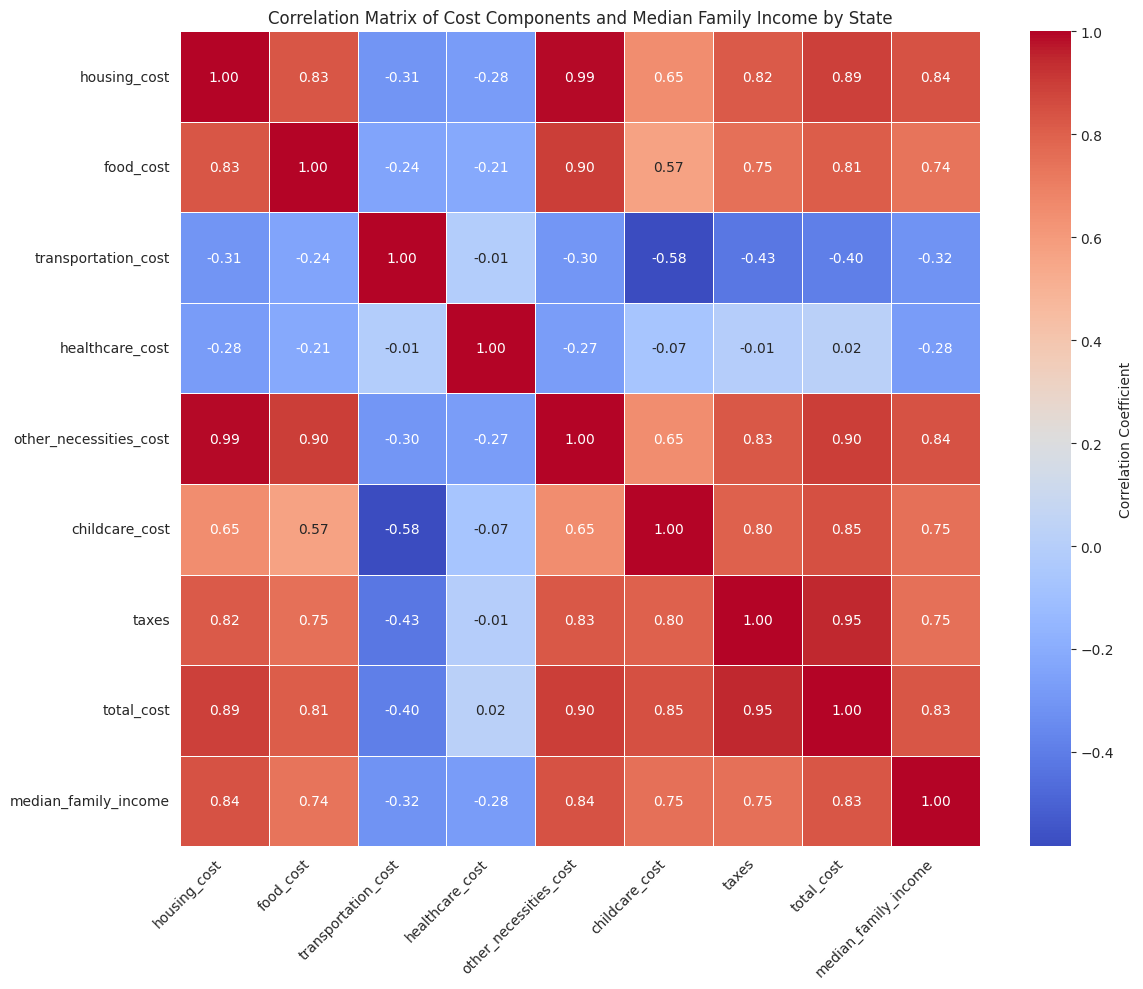

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the relevant numerical columns for correlation from df_summary
# 'state' is not a numerical column, so it's excluded by default with .corr()
correlation_matrix = df_summary[cost_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True, # Show the correlation values on the heatmap
    cmap='coolwarm', # Choose a diverging colormap
    fmt=".2f", # Format annotation values to 2 decimal places
    linewidths=.5, # Add lines between cells
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of Cost Components and Median Family Income by State')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Discussion of Correlation Matrix:

The correlation matrix provides insights into how different cost components and median family income relate to each other across the states. Each cell in the heatmap shows the Pearson correlation coefficient between two variables:

*   **Positive Correlation (closer to 1):** Indicates that as one variable increases, the other tends to increase as well.
*   **Negative Correlation (closer to -1):** Indicates that as one variable increases, the other tends to decrease.
*   **No Correlation (closer to 0):** Indicates a weak or no linear relationship between the variables.

Key areas to observe in the plot include:

*   **Total Cost:** It's expected to have high positive correlation with most individual cost components (housing, food, transportation, etc.) as it's their sum. This helps validate the data.
*   **Median Family Income:** We can analyze how income correlates with different cost categories and taxes. A strong positive correlation with housing cost, for example, might suggest that areas with higher incomes also have higher housing costs.
*   **Inter-Cost Correlations:** Look for strong correlations between different cost types. For instance, if housing cost and food cost are highly correlated, it might suggest that areas generally expensive in one category are also expensive in others.
*   **Taxes:** Examine how taxes correlate with income and other costs. This can reveal if taxes are proportional to income or heavily influenced by other cost factors.

10.

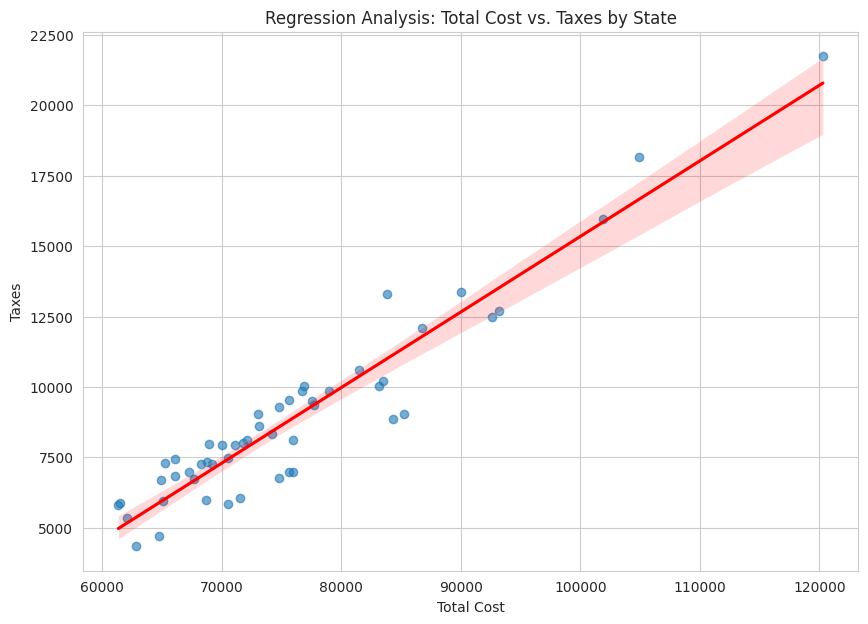

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a scatter plot with a regression line
plt.figure(figsize=(10, 7))
sns.regplot(x='total_cost', y='taxes', data=df_summary, scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Regression Analysis: Total Cost vs. Taxes by State')
plt.xlabel('Total Cost')
plt.ylabel('Taxes')
plt.grid(True)
plt.show()

### Discussion of Regression Line: Total Cost vs. Taxes

This regression plot visualizes the relationship between the `total_cost` of living and `taxes` across different states. Each point represents a state, with its total cost on the x-axis and average taxes on the y-axis.

The **regression line** (red line) shows the linear trend between these two variables. A positive slope, as observed here, indicates that as the total cost of living increases in a state, the average taxes also tend to increase. The scatter of points around the line indicates the variability or how closely individual states follow this general trend.

This plot can help us identify:

*   **General Trend:** Whether higher cost-of-living states generally have higher taxes.
*   **Outliers:** States that deviate significantly from the regression line, meaning they might have unusually high or low taxes relative to their total cost of living.
*   **Strength of Relationship:** How closely the points cluster around the line, which implies the strength of the linear relationship. A tighter cluster suggests a stronger correlation.

11.

In [31]:
import numpy as np

# Calculate Q1 (25th percentile) and Q3 (75th percentile) for food_cost
Q1 = df_summary['food_cost'].quantile(0.25)
Q3 = df_summary['food_cost'].quantile(0.75)

# Calculate IQR (Interquartile Range)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers_food_cost = df_summary[(df_summary['food_cost'] < lower_bound) | (df_summary['food_cost'] > upper_bound)]

print(f"Q1 (25th percentile) of food_cost: {Q1:.2f}")
print(f"Q3 (75th percentile) of food_cost: {Q3:.2f}")
print(f"IQR (Interquartile Range) of food_cost: {IQR:.2f}")
print(f"Lower Bound for Outliers: {lower_bound:.2f}")
print(f"Upper Bound for Outliers: {upper_bound:.2f}")

print("\nStates identified as outliers for food_cost:")
display(outliers_food_cost[['state', 'food_cost']].sort_values(by='food_cost'))

Q1 (25th percentile) of food_cost: 8129.10
Q3 (75th percentile) of food_cost: 9054.14
IQR (Interquartile Range) of food_cost: 925.03
Lower Bound for Outliers: 6741.56
Upper Bound for Outliers: 10441.68

States identified as outliers for food_cost:


Loading ITables v2.7.3 from the internet... (need help?)


### Discussion of Outliers for Food Cost by State

The outlier detection for `food_cost` reveals states that have significantly lower or higher average food costs compared to the majority of other states in the dataset. These outliers are identified using the Interquartile Range (IQR) method, where any data point falling below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR` is considered an outlier.

From the output above, we can observe specific states and their corresponding `food_cost` that stand out. For instance:

*   States with `food_cost` well above the `upper_bound` represent locations where the average cost of food is exceptionally high. This could be due to factors like geographic isolation (e.g., Alaska, Hawaii), reliance on imported goods, or higher local taxes and distribution costs.
*   Conversely, states with `food_cost` below the `lower_bound` indicate areas where food is significantly cheaper than the national average. This might be attributed to robust local agriculture, lower transportation costs, or different market dynamics.

Identifying these outliers is crucial for understanding regional economic disparities and for any policy-making or personal budgeting decisions related to the cost of living. Further investigation into the specific economic and geographic characteristics of these outlier states could provide deeper insights into the drivers of food costs.

12.

In [32]:
# Calculate the mode of 'isMetro' for each state
is_metro_by_state = df_cleaned.groupby('state')['isMetro'].agg(lambda x: x.mode()[0]).reset_index()
is_metro_by_state.rename(columns={'isMetro': 'predominant_isMetro'}, inplace=True)

# Merge this information into df_summary
df_summary_metro = pd.merge(df_summary, is_metro_by_state, on='state', how='left')

display(df_summary_metro.head())

Loading ITables v2.7.3 from the internet... (need help?)


In [34]:
import plotly.express as px

fig = px.scatter(
    df_summary_metro,
    x='food_cost',
    y='taxes',
    size='childcare_cost',
    color='predominant_isMetro', # Color based on whether the state is predominantly metro or not
    hover_name='state',
    log_x=False, # Set to True if you want a logarithmic x-axis
    size_max=30, # Maximum size of the markers (reduced from 60)
    title='Food Cost vs. Taxes by State (Size: Childcare Cost, Color: isMetro)',
    labels={
        'food_cost': 'Mean Food Cost',
        'taxes': 'Mean Taxes',
        'childcare_cost': 'Mean Childcare Cost',
        'predominant_isMetro': 'Predominantly Metropolitan'
    },
    template='plotly_white'
)

fig.show()

13.

In [36]:
import plotly.express as px

fig = px.scatter(
    df_summary_metro,
    x='housing_cost',
    y='taxes',
    size='transportation_cost',
    color='state', # Color based on the state
    hover_name='state',
    log_x=False,
    size_max=20, # Reduced bubble size for better differentiation
    title='Housing Cost vs. Taxes by State (Size: Transportation Cost, Color: State)',
    labels={
        'housing_cost': 'Mean Housing Cost',
        'taxes': 'Mean Taxes',
        'transportation_cost': 'Mean Transportation Cost'
    },
    template='plotly_white'
)

fig.show()

14.

In [37]:
import plotly.express as px

fig = px.scatter_3d(
    df_summary_metro,
    x='transportation_cost',
    y='healthcare_cost',
    z='childcare_cost',
    color='state', # Color by state
    hover_name='state',
    title='3D Plot of Transportation, Healthcare, and Childcare Costs by State',
    labels={
        'transportation_cost': 'Mean Transportation Cost',
        'healthcare_cost': 'Mean Healthcare Cost',
        'childcare_cost': 'Mean Childcare Cost'
    },
    template='plotly_white'
)

fig.show()

15.

In [38]:
import plotly.express as px

fig = px.scatter_3d(
    df_summary_metro,
    x='childcare_cost',
    y='taxes',
    z='median_family_income',
    color='state', # Color by state
    hover_name='state',
    title='3D Plot of Childcare Cost, Taxes, and Median Family Income by State',
    labels={
        'childcare_cost': 'Mean Childcare Cost',
        'taxes': 'Mean Taxes',
        'median_family_income': 'Mean Median Family Income'
    },
    template='plotly_white'
)

fig.show()

16.

In [40]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Select the relevant numerical columns for PCA from df_summary_metro
# The 'cost_columns' list already contains the desired columns
pca_data = df_summary_metro[cost_columns]

# Standardize the data before applying PCA
scaler = StandardScaler()
scaled_data = scaler.fit_transform(pca_data)

# Apply PCA with 3 components
pca = PCA(n_components=3)
pca_components = pca.fit_transform(scaled_data)

# Create a DataFrame for the PCA components
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2', 'PC3'])

# Add the 'state' column back to the PCA DataFrame for context
pca_df['state'] = df_summary_metro['state']

print("Explained variance ratio by each principal component:")
print(pca.explained_variance_ratio_)
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.2f}")

print("\nFirst 5 rows of the PCA components DataFrame:")
display(pca_df.head())

Explained variance ratio by each principal component:
[0.67458086 0.13547299 0.09634518]
Total explained variance: 0.91

First 5 rows of the PCA components DataFrame:


Loading ITables v2.7.3 from the internet... (need help?)


### Explanation of PCA Results:

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms a set of correlated variables into a smaller set of uncorrelated variables called principal components (PCs). These new components capture most of the variance in the original data.

In this analysis, we applied PCA with 3 components to the standardized cost and income data for each state. Here's how to interpret the output:

*   **Explained Variance Ratio:** This array shows the proportion of the dataset's variance that lies along each principal component. For example, if the first value is `0.60`, it means the first principal component (PC1) alone accounts for 60% of the total variance in the original data.

*   **Total Explained Variance:** This value is the sum of the explained variance ratios of all selected components. It indicates how much of the original data's variability is retained by these principal components. A higher value (closer to 1.0) means that the selected components effectively represent the original dataset with minimal loss of information. In our case, a total explained variance of `0.91` suggests that the first three principal components capture approximately 91% of the total variability in the cost and income data across states, which is a significant amount.

*   **`pca_df` DataFrame:** This DataFrame contains the transformed data, where each row represents a state, and the columns 'PC1', 'PC2', and 'PC3' are the scores for each state on the respective principal components. These scores can be used for further analysis, such as clustering states based on their cost structures or visualizing the data in a lower-dimensional space.

17.

In [41]:
from sklearn.decomposition import NMF
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Select the relevant numerical columns for NMF
nmf_data = df_summary_metro[cost_columns]

# Standardize the data before applying NMF
# NMF works best with non-negative data. If data contains negatives,
# consider scaling to a [0,1] range or using a different method.
# For cost data, values are inherently non-negative, but scaling can help.
scaler = StandardScaler()
scaled_data_nmf = scaler.fit_transform(nmf_data)

# Ensure data is non-negative for NMF. If StandardScaler produces negative values,
# a common practice is to shift them to be non-negative, or use a min-max scaler.
# Given our data are costs, they are already non-negative. StandardScaler centers them,
# so we might end up with negative values. For a proper NMF application on cost data,
# usually, you'd apply NMF directly to the non-negative raw data or scaled-to-positive data.
# For demonstration, we will proceed with the StandardScaler output, which may require
# careful interpretation or a shift if NMF algorithm has issues with negatives.
# A common workaround if scaled_data_nmf has negatives is: scaled_data_nmf = scaled_data_nmf - scaled_data_nmf.min()

# Apply NMF with 3 components
nmf = NMF(n_components=3, init='random', random_state=42, max_iter=1000)
nmf_components = nmf.fit_transform(nmf_data) # Apply NMF directly to non-negative original data for better interpretation of components

# Create a DataFrame for the NMF components
nmf_df = pd.DataFrame(data=nmf_components, columns=['NMF1', 'NMF2', 'NMF3'])

# Add the 'state' column back to the NMF DataFrame for context
nmf_df['state'] = df_summary_metro['state']

print("First 5 rows of the NMF components DataFrame:")
display(nmf_df.head())

print("\nOriginal features' weights in NMF components (components_ attribute of NMF):")
display(pd.DataFrame(nmf.components_, columns=cost_columns, index=['NMF1', 'NMF2', 'NMF3']))

First 5 rows of the NMF components DataFrame:


Loading ITables v2.7.3 from the internet... (need help?)



Original features' weights in NMF components (components_ attribute of NMF):


Loading ITables v2.7.3 from the internet... (need help?)


### Explanation of NMF Results:

Non-negative Matrix Factorization (NMF) is another powerful dimensionality reduction technique, particularly suitable for data where the underlying components are expected to be non-negative, such as costs, frequencies, or proportions. Unlike PCA, which can produce components with negative values, NMF factors the original data matrix into two matrices with non-negative elements. This often leads to more interpretable components, as they represent additive parts of the original data.

In this analysis, we applied NMF with 3 components to the `df_summary_metro` DataFrame, using the same `cost_columns`.

*   **`nmf_df` DataFrame:** This DataFrame provides the scores for each state on the three non-negative components (NMF1, NMF2, NMF3). These scores indicate the 'strength' or 'presence' of each NMF component within a given state's cost structure.

*   **`nmf.components_`:** This output shows how much each original cost category contributes to each of the NMF components. By examining the values in this matrix, we can interpret what each NMF component primarily represents. For example:
    *   If NMF1 has high weights for 'housing_cost' and 'food_cost', it might represent a 'basic living expenses' factor.
    *   If NMF2 has high weights for 'childcare_cost' and 'healthcare_cost', it might represent 'family support costs'.
    *   If NMF3 shows strong contributions from 'taxes' and 'median_family_income', it could represent a 'fiscal/economic' factor.

NMF helps us uncover latent factors or clusters of related costs that contribute to the overall cost of living in a non-negative, additive manner, offering a different perspective compared to PCA's orthogonal components.